In [2]:
import pandas as pd
import numpy as np

In [3]:
movies = pd.read_csv("movies.csv")
directors = pd.read_csv("directors.csv")

In [4]:
movies

,Unnamed: 0,id,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day
0,0,43597,237000000,150,2787965087,Avatar,7.2,11800,4762,2009,Dec,Thursday
1,1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday
2,2,43599,245000000,107,880674609,Spectre,6.3,4466,4764,2015,Oct,Monday
3,3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday
4,5,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...
1460,4736,48363,0,3,321952,The Last Waltz,7.9,64,4809,1978,May,Monday
1461,4743,48370,27000,19,3151130,Clerks,7.4,755,5369,1994,Sep,Tuesday
1462,4748,48375,0,7,0,Rampage,6.0,131,5148,2009,Aug,Friday
1463,4749,48376,0,3,0,Slacker,6.4,77,5535,1990,Jul,Friday


In [5]:
directors.head()

,Unnamed: 0,director_name,id,gender
0,0,James Cameron,4762,Male
1,1,Gore Verbinski,4763,Male
2,2,Sam Mendes,4764,Male
3,3,Christopher Nolan,4765,Male
4,4,Andrew Stanton,4766,Male


In [6]:
a = pd.DataFrame({'A':[10,30],'B':[20,40]})
b = pd.DataFrame({'A':[10,30],'C':[20,40]})

In [7]:
a

,A,B
0,10,20
1,30,40


In [8]:
b

,A,C
0,10,20
1,30,40


In [9]:
pd.concat([a,b],axis=0)

,A,B,C
0,10,20.0,NaN
1,30,40.0,NaN
0,10,NaN,20.0
1,30,NaN,40.0


In [10]:
pd.concat([a,b],axis=1)

,A,B,A,C
0,10,20,10,20
1,30,40,30,40


In [11]:
pd.concat([a,b],keys=["x","y"]).loc["x"]

,A,B,C
0,10,20.0,NaN
1,30,40.0,NaN


In [12]:
# inner connection
pd.concat([a,b],axis=0,join="inner")

,A
0,10
1,30
0,10
1,30


In [13]:
# Merge = Join Side by Side 

In [14]:
users = pd.DataFrame({'userid':[1,2,3],'name':['A','B','C']})
msgs = pd.DataFrame({'userid':[1,1,2],'msg':['hello','bye','hi']})

In [15]:
users

,userid,name
0,1,A
1,2,B
2,3,C


In [16]:
msgs

,userid,msg
0,1,hello
1,1,bye
2,2,hi


In [17]:
pd.concat([users,msgs],axis=1) # What's that ?

,userid,name,userid,msg
0,1,A,1,hello
1,2,B,1,bye
2,3,C,2,hi


In [18]:
msgs.merge(users,on="userid")

,userid,msg,name
0,1,hello,A
1,1,bye,A
2,2,hi,B


In [19]:
users = pd.DataFrame({'userid':[1,2,3],'name':['A','B','C']})
msgs = pd.DataFrame({'userid':[1,1,2],'msg':['hello','bye','hi']})

In [20]:
users.rename(columns={"userid":"id"},inplace=True)
users

,id,name
0,1,A
1,2,B
2,3,C


In [21]:
msgs

,userid,msg
0,1,hello
1,1,bye
2,2,hi


In [22]:
users.merge(msgs,left_on="id",right_on="userid")

,id,name,userid,msg
0,1,A,1,hello
1,1,A,1,bye
2,2,B,2,hi


In [23]:
# inner,outer,left,right

In [24]:
users.merge(msgs,left_on="id",right_on="userid",how="inner")

,id,name,userid,msg
0,1,A,1,hello
1,1,A,1,bye
2,2,B,2,hi


In [25]:
users.merge(msgs,left_on="id",right_on="userid",how="outer")


,id,name,userid,msg
0,1,A,1.0,hello
1,1,A,1.0,bye
2,2,B,2.0,hi
3,3,C,NaN,NaN


In [26]:
users.merge(msgs,left_on="id",right_on="userid",how="left")


,id,name,userid,msg
0,1,A,1.0,hello
1,1,A,1.0,bye
2,2,B,2.0,hi
3,3,C,NaN,NaN


In [27]:
users.merge(msgs,left_on="id",right_on="userid",how="right")


,id,name,userid,msg
0,1,A,1,hello
1,1,A,1,bye
2,2,B,2,hi


In [28]:
movies

,Unnamed: 0,id,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day
0,0,43597,237000000,150,2787965087,Avatar,7.2,11800,4762,2009,Dec,Thursday
1,1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday
2,2,43599,245000000,107,880674609,Spectre,6.3,4466,4764,2015,Oct,Monday
3,3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday
4,5,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...
1460,4736,48363,0,3,321952,The Last Waltz,7.9,64,4809,1978,May,Monday
1461,4743,48370,27000,19,3151130,Clerks,7.4,755,5369,1994,Sep,Tuesday
1462,4748,48375,0,7,0,Rampage,6.0,131,5148,2009,Aug,Friday
1463,4749,48376,0,3,0,Slacker,6.4,77,5535,1990,Jul,Friday


In [29]:
directors

,Unnamed: 0,director_name,id,gender
0,0,James Cameron,4762,Male
1,1,Gore Verbinski,4763,Male
2,2,Sam Mendes,4764,Male
3,3,Christopher Nolan,4765,Male
4,4,Andrew Stanton,4766,Male
...,...,...,...,...
2344,2344,Shane Carruth,7106,Male
2345,2345,Neill Dela Llana,7107,NaN
2346,2346,Scott Smith,7108,NaN
2347,2347,Daniel Hsia,7109,Male


In [30]:
movies = pd.read_csv("movies.csv",index_col=0)

In [31]:
movies

,id,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day
0,43597,237000000,150,2787965087,Avatar,7.2,11800,4762,2009,Dec,Thursday
1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday
2,43599,245000000,107,880674609,Spectre,6.3,4466,4764,2015,Oct,Monday
3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday
5,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
4736,48363,0,3,321952,The Last Waltz,7.9,64,4809,1978,May,Monday
4743,48370,27000,19,3151130,Clerks,7.4,755,5369,1994,Sep,Tuesday
4748,48375,0,7,0,Rampage,6.0,131,5148,2009,Aug,Friday
4749,48376,0,3,0,Slacker,6.4,77,5535,1990,Jul,Friday


In [32]:
directors = pd.read_csv("directors.csv",index_col=0)


In [33]:
directors

,director_name,id,gender
0,James Cameron,4762,Male
1,Gore Verbinski,4763,Male
2,Sam Mendes,4764,Male
3,Christopher Nolan,4765,Male
4,Andrew Stanton,4766,Male
...,...,...,...
2344,Shane Carruth,7106,Male
2345,Neill Dela Llana,7107,NaN
2346,Scott Smith,7108,NaN
2347,Daniel Hsia,7109,Male


In [34]:
movies.shape

(1465, 11)

In [35]:
directors.shape

(2349, 3)

* left outer join to keep all movie and some directors

In [36]:
movies["director_id"].unique()

array([4762, 4763, 4764, 4765, 4767, 4771, 4772, 4773, 4774, 4775, 4776,
       4777, 4779, 4780, 4782, 4785, 4786, 4788, 4791, 4793, 4794, 4797,
       4798, 4799, 4802, 4803, 4804, 4805, 4808, 4809, 4810, 4811, 4812,
       4813, 4814, 4829, 4831, 4832, 4833, 4838, 4839, 4842, 4845, 4846,
       4847, 4849, 4854, 4857, 4858, 4859, 4863, 4865, 4866, 4867, 4868,
       4872, 4873, 4874, 4876, 4880, 4881, 4885, 4886, 4888, 4889, 4890,
       4892, 4893, 4894, 4900, 4904, 4909, 4913, 4915, 4917, 4918, 4921,
       4923, 4924, 4925, 4926, 4927, 4930, 4935, 4936, 4945, 4947, 4948,
       4949, 4955, 4958, 4960, 4964, 4965, 4967, 4974, 4978, 4989, 4991,
       4993, 4995, 4998, 5002, 5005, 5008, 5009, 5014, 5017, 5024, 5031,
       5033, 5034, 5035, 5037, 5039, 5047, 5053, 5056, 5059, 5061, 5067,
       5082, 5087, 5088, 5093, 5096, 5097, 5101, 5105, 5111, 5113, 5115,
       5116, 5123, 5125, 5130, 5132, 5135, 5140, 5147, 5148, 5152, 5157,
       5162, 5179, 5182, 5191, 5193, 5195, 5196, 52

In [37]:
len(movies["director_id"].unique())
# or 
movies["director_id"].nunique()

199

In [38]:
directors["id"].nunique()

2349

In [39]:
# Check Movie director in directors dataset
movies["director_id"].isin(directors["id"])

# We have to insure that all must true

0       True
1       True
2       True
3       True
5       True
        ... 
4736    True
4743    True
4748    True
4749    True
4768    True
Name: director_id, Length: 1465, dtype: bool

In [40]:
np.all(movies["director_id"].isin(directors["id"])) # all are true

np.True_

In [41]:
data = movies.merge(directors,left_on="director_id",right_on="id",how="left")

In [42]:
data.head()

,id_x,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day,director_name,id_y,gender
0,43597,237000000,150,2787965087,Avatar,7.2,11800,4762,2009,Dec,Thursday,James Cameron,4762,Male
1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday,Gore Verbinski,4763,Male
2,43599,245000000,107,880674609,Spectre,6.3,4466,4764,2015,Oct,Monday,Sam Mendes,4764,Male
3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday,Christopher Nolan,4765,Male
4,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday,Sam Raimi,4767,Male


In [43]:
# idx is movie id
# idy is director id

# Which col are redundant ? 
# director_id and idy

In [44]:
data.drop(["director_id","id_y"],axis=1,inplace=True)

In [45]:
data

,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
0,43597,237000000,150,2787965087,Avatar,7.2,11800,2009,Dec,Thursday,James Cameron,Male
1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,2007,May,Saturday,Gore Verbinski,Male
2,43599,245000000,107,880674609,Spectre,6.3,4466,2015,Oct,Monday,Sam Mendes,Male
3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,2012,Jul,Monday,Christopher Nolan,Male
4,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,2007,May,Tuesday,Sam Raimi,Male
...,...,...,...,...,...,...,...,...,...,...,...,...
1460,48363,0,3,321952,The Last Waltz,7.9,64,1978,May,Monday,Martin Scorsese,Male
1461,48370,27000,19,3151130,Clerks,7.4,755,1994,Sep,Tuesday,Kevin Smith,Male
1462,48375,0,7,0,Rampage,6.0,131,2009,Aug,Friday,Uwe Boll,Male
1463,48376,0,3,0,Slacker,6.4,77,1990,Jul,Friday,Richard Linklater,Male


In [46]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_x           1465 non-null   int64  
 1   budget         1465 non-null   int64  
 2   popularity     1465 non-null   int64  
 3   revenue        1465 non-null   int64  
 4   title          1465 non-null   str    
 5   vote_average   1465 non-null   float64
 6   vote_count     1465 non-null   int64  
 7   year           1465 non-null   int64  
 8   month          1465 non-null   str    
 9   day            1465 non-null   str    
 10  director_name  1465 non-null   str    
 11  gender         1341 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 137.5 KB


In [47]:
data.describe()

,id_x,budget,popularity,revenue,vote_average,vote_count,year
count,1465.000000,1.465000e+03,1465.000000,1.465000e+03,1465.000000,1465.000000,1465.000000
mean,45225.191126,4.802295e+07,30.855973,1.432539e+08,6.368191,1146.396587,2002.615017
std,1189.096396,4.935541e+07,34.845214,2.064918e+08,0.818033,1578.077438,8.680141
min,43597.000000,0.000000e+00,0.000000,0.000000e+00,3.000000,1.000000,1976.000000
25%,44236.000000,1.400000e+07,11.000000,1.738013e+07,5.900000,216.000000,1998.000000
50%,45022.000000,3.300000e+07,23.000000,7.578164e+07,6.400000,571.000000,2004.000000
75%,45990.000000,6.600000e+07,41.000000,1.792469e+08,6.900000,1387.000000,2009.000000
max,48395.000000,3.800000e+08,724.000000,2.787965e+09,8.300000,13752.000000,2016.000000


In [48]:
data.describe(include="object")

C:\Users\anura\AppData\Local\Temp\ipykernel_21644\460854327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object")


,title,month,day,director_name,gender
count,1465,1465,1465,1465,1341
unique,1465,12,7,199,2
top,Avatar,Dec,Friday,Steven Spielberg,Male
freq,1,193,654,26,1309


In [49]:
print("Hello")

Hello


In [50]:
data["revenue"] = data["revenue"]/1000000

In [51]:
data["budget"] = data["budget"]/1000000

In [52]:
# Querying dataframe to fetch th data

In [53]:
data.loc[data["vote_average"]>=8].head()

,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
45,43662,185.0,187,1004.558444,The Dark Knight,8.2,12002,2008,Jul,Wednesday,Christopher Nolan,Male
58,43692,165.0,724,675.120017,Interstellar,8.1,10867,2014,Nov,Wednesday,Christopher Nolan,Male
59,43693,160.0,167,825.532764,Inception,8.1,13752,2010,Jul,Wednesday,Christopher Nolan,Male
156,43859,93.0,138,871.368364,The Lord of the Rings: The Fellowship of the Ring,8.0,8705,2001,Dec,Tuesday,Peter Jackson,Male
199,43926,94.0,123,1118.888979,The Lord of the Rings: The Return of the King,8.1,8064,2003,Dec,Monday,Peter Jackson,Male


In [54]:
data.loc[data["vote_average"]>=8,["title","vote_average"]].head()


,title,vote_average
45,The Dark Knight,8.2
58,Interstellar,8.1
59,Inception,8.1
156,The Lord of the Rings: The Fellowship of the Ring,8.0
199,The Lord of the Rings: The Return of the King,8.1


In [55]:
# Highly rated latest movie 
data.loc[(data["vote_average"]>=7) & (data["year"]>=2015)].head()


,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
30,43641,190.0,102,1506.249360,Furious 7,7.3,4176,2015,Apr,Wednesday,James Wan,Male
78,43724,150.0,434,378.858340,Mad Max: Fury Road,7.2,9427,2015,May,Wednesday,George Miller,Male
106,43773,135.0,100,532.950503,The Revenant,7.3,6396,2015,Dec,Friday,Alejandro González Iñárritu,Male
162,43867,108.0,167,630.161890,The Martian,7.6,7268,2015,Sep,Wednesday,Ridley Scott,Male
312,44128,75.0,48,108.145109,The Man from U.N.C.L.E.,7.1,2265,2015,Aug,Thursday,Guy Ritchie,Male


In [56]:
# Strings methods

In [57]:
data.loc[data["title"].str.startswith("Batman")]

,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
5,43606,250.0,155,873.260194,Batman v Superman: Dawn of Justice,5.7,7004,2016,Mar,Wednesday,Zack Snyder,Male
74,43716,150.0,115,374.218673,Batman Begins,7.5,7359,2005,Jun,Friday,Christopher Nolan,Male
128,43807,125.0,50,238.207122,Batman & Robin,4.2,1418,1997,Jun,Friday,Joel Schumacher,Male
184,43896,100.0,48,336.529144,Batman Forever,5.2,1498,1995,May,Wednesday,Joel Schumacher,Male
257,44025,80.0,59,280.000000,Batman Returns,6.6,1673,1992,Jun,Friday,Tim Burton,Male
704,44956,35.0,44,411.348924,Batman,7.0,2096,1989,Jun,Friday,Tim Burton,Male


In [66]:
# Movie title start with the
data.loc[data["title"].str.contains("The")]


,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
3,43600,250.00,112,1084.939099,The Dark Knight Rises,7.6,9106,2012,Jul,Monday,Christopher Nolan,Male
9,43610,255.00,49,89.289910,The Lone Ranger,5.9,2311,2013,Jul,Wednesday,Gore Verbinski,Male
11,43612,225.00,53,419.651413,The Chronicles of Narnia: Prince Caspian,6.3,1630,2008,May,Thursday,Andrew Adamson,Male
14,43616,250.00,120,956.019788,The Hobbit: The Battle of the Five Armies,7.1,4760,2014,Dec,Wednesday,Peter Jackson,Male
16,43619,250.00,94,958.400000,The Hobbit: The Desolation of Smaug,7.6,4524,2013,Dec,Wednesday,Peter Jackson,Male
...,...,...,...,...,...,...,...,...,...,...,...,...
1440,48155,0.00,0,0.000000,Alleluia! The Devil's Carnival,6.0,2,2016,Mar,Tuesday,Darren Lynn Bousman,Male
1443,48192,0.35,35,29.400000,The Evil Dead,7.3,894,1981,Oct,Thursday,Sam Raimi,Male
1449,48244,0.25,6,0.056825,The Canyons,4.1,75,2013,Jul,Monday,Paul Schrader,NaN
1457,48323,0.00,5,0.000000,The Mighty,7.1,51,1998,Oct,Friday,Peter Chelsom,Male


In [58]:
# Top 5 popular Movie 

data.sort_values("popularity",ascending=False).head()

,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
58,43692,165.0,724,675.120017,Interstellar,8.1,10867,2014,Nov,Wednesday,Christopher Nolan,Male
78,43724,150.0,434,378.858340,Mad Max: Fury Road,7.2,9427,2015,May,Wednesday,George Miller,Male
119,43796,140.0,271,655.011224,Pirates of the Caribbean: The Curse of the Bla...,7.5,6985,2003,Jul,Wednesday,Gore Verbinski,Male
120,43797,125.0,206,752.100229,The Hunger Games: Mockingjay - Part 1,6.6,5584,2014,Nov,Tuesday,Francis Lawrence,Male
45,43662,185.0,187,1004.558444,The Dark Knight,8.2,12002,2008,Jul,Wednesday,Christopher Nolan,Male


In [59]:
data.loc[data["director_name"]=="Christopher Nolan","title"] 

3       The Dark Knight Rises
45            The Dark Knight
58               Interstellar
59                  Inception
74              Batman Begins
565                  Insomnia
641              The Prestige
1341                  Memento
Name: title, dtype: str

In [60]:
data.loc[(data["month"]=="Jan") | (data["month"]=="Nov")]

,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
19,43622,200.000,100,1845.034188,Titanic,7.5,7562,1997,Nov,Tuesday,James Cameron,Male
41,43657,200.000,39,325.233863,A Christmas Carol,6.6,1095,2009,Nov,Wednesday,Robert Zemeckis,Male
47,43666,170.000,32,185.770160,Hugo,7.0,2141,2011,Nov,Tuesday,Martin Scorsese,Male
56,43687,165.000,47,305.875730,The Polar Express,6.4,1474,2004,Nov,Wednesday,Robert Zemeckis,Male
58,43692,165.000,724,675.120017,Interstellar,8.1,10867,2014,Nov,Wednesday,Christopher Nolan,Male
...,...,...,...,...,...,...,...,...,...,...,...,...
1441,48162,0.000,7,0.773228,Bloody Sunday,7.2,53,2002,Jan,Wednesday,Paul Greengrass,Male
1444,48204,0.312,1,1.281176,Tumbleweeds,6.2,11,1999,Nov,Sunday,Gavin O'Connor,Male
1447,48231,0.000,3,0.000000,Better Luck Tomorrow,6.5,27,2002,Jan,Saturday,Justin Lin,NaN
1448,48233,0.000,0,0.000000,Chuck & Buck,5.7,16,2000,Jan,Friday,Miguel Arteta,Male


In [61]:
# Know no of movie released by  particular director
data.loc[data["director_name"]=="Christopher Nolan","title"].count() 

np.int64(8)

In [62]:
data["director_name"].value_counts()

director_name
Steven Spielberg       26
Martin Scorsese        19
Clint Eastwood         19
Woody Allen            18
Ridley Scott           16
                       ..
Mike Leigh              5
Brad Anderson           5
Michael Polish          5
Darren Lynn Bousman     5
Nicole Holofcener       5
Name: count, Length: 199, dtype: int64

In [63]:
# Highest Budget movie of each director ?

data.groupby("director_name")["budget"].max()

director_name
Adam McKay                     100.0
Adam Shankman                   80.0
Alejandro González Iñárritu    135.0
Alex Proyas                    140.0
Alexander Payne                 30.0
                               ...  
Wes Craven                      40.0
Wolfgang Petersen              175.0
Woody Allen                     30.0
Zack Snyder                    250.0
Zhang Yimou                     94.0
Name: budget, Length: 199, dtype: float64

In [64]:
data.groupby("director_name")["title"].count()


director_name
Adam McKay                      6
Adam Shankman                   8
Alejandro González Iñárritu     6
Alex Proyas                     5
Alexander Payne                 5
                               ..
Wes Craven                     10
Wolfgang Petersen               7
Woody Allen                    18
Zack Snyder                     7
Zhang Yimou                     6
Name: title, Length: 199, dtype: int64

In [65]:
# Which Director is the most productive direct

In [66]:
# Budget
# Number of Movies
# quality - vote_average

In [67]:
data.groupby("director_name")["title"].count().sort_values(ascending=False)


director_name
Steven Spielberg    26
Martin Scorsese     19
Clint Eastwood      19
Woody Allen         18
Robert Rodriguez    16
                    ..
Stephen Daldry       5
Tom Tykwer           5
Tim Hill             5
Uwe Boll             5
Wayne Wang           5
Name: title, Length: 199, dtype: int64

In [68]:
# Average number of movies directed per year

In [69]:
# active_year = last_working_year-first_working_year

In [70]:
data.groupby("director_name")["year"].min()



director_name
Adam McKay                     2004
Adam Shankman                  2001
Alejandro González Iñárritu    2000
Alex Proyas                    1994
Alexander Payne                1999
                               ... 
Wes Craven                     1984
Wolfgang Petersen              1981
Woody Allen                    1977
Zack Snyder                    2004
Zhang Yimou                    2002
Name: year, Length: 199, dtype: int64

In [71]:
data.groupby("director_name")["year"].max()


director_name
Adam McKay                     2015
Adam Shankman                  2012
Alejandro González Iñárritu    2015
Alex Proyas                    2016
Alexander Payne                2013
                               ... 
Wes Craven                     2011
Wolfgang Petersen              2006
Woody Allen                    2013
Zack Snyder                    2016
Zhang Yimou                    2014
Name: year, Length: 199, dtype: int64

In [72]:
df_agg = data.groupby("director_name")[["year","title"]].aggregate({"year":["min","max"],"title":["count"]})

In [73]:
df_agg.columns

MultiIndex([( 'year',   'min'),
            ( 'year',   'max'),
            ('title', 'count')],
           )

In [74]:
df_agg["year"]

,min,max
director_name,,
Adam McKay,2004,2015
Adam Shankman,2001,2012
Alejandro González Iñárritu,2000,2015
Alex Proyas,1994,2016
Alexander Payne,1999,2013
...,...,...
Wes Craven,1984,2011
Wolfgang Petersen,1981,2006
Woody Allen,1977,2013


In [75]:
df_agg["title"]

,count
director_name,
Adam McKay,6
Adam Shankman,8
Alejandro González Iñárritu,6
Alex Proyas,5
Alexander Payne,5
...,...
Wes Craven,10
Wolfgang Petersen,7
Woody Allen,18


In [76]:
df_agg.columns = ["_".join(col) for col in df_agg.columns]

In [77]:
df_agg.columns

Index(['year_min', 'year_max', 'title_count'], dtype='str')

In [93]:
df_agg

,year_min,year_max,title_count
director_name,,,
Adam McKay,2004,2015,6
Adam Shankman,2001,2012,8
Alejandro González Iñárritu,2000,2015,6
Alex Proyas,1994,2016,5
Alexander Payne,1999,2013,5
...,...,...,...
Wes Craven,1984,2011,10
Wolfgang Petersen,1981,2006,7
Woody Allen,1977,2013,18


In [96]:
df_agg.reset_index(inplace=True)

In [ ]:
df_agg["active_yrs"] = df_agg["year_max"] -  df_agg["year_min"]

In [98]:
df_agg

,director_name,year_min,year_max,title_count,active_yrs
0,Adam McKay,2004,2015,6,11
1,Adam Shankman,2001,2012,8,11
2,Alejandro González Iñárritu,2000,2015,6,15
3,Alex Proyas,1994,2016,5,22
4,Alexander Payne,1999,2013,5,14
...,...,...,...,...,...
194,Wes Craven,1984,2011,10,27
195,Wolfgang Petersen,1981,2006,7,25
196,Woody Allen,1977,2013,18,36
197,Zack Snyder,2004,2016,7,12


In [105]:
df_agg["movie_per_yr"] = df_agg["title_count"] /  df_agg["active_yrs"]


In [106]:
df_agg

,director_name,year_min,year_max,title_count,active_yrs,movie_per_yr
0,Adam McKay,2004,2015,6,11,0.545455
1,Adam Shankman,2001,2012,8,11,0.727273
2,Alejandro González Iñárritu,2000,2015,6,15,0.400000
3,Alex Proyas,1994,2016,5,22,0.227273
4,Alexander Payne,1999,2013,5,14,0.357143
...,...,...,...,...,...,...
194,Wes Craven,1984,2011,10,27,0.370370
195,Wolfgang Petersen,1981,2006,7,25,0.280000
196,Woody Allen,1977,2013,18,36,0.500000
197,Zack Snyder,2004,2016,7,12,0.583333


In [107]:
df_agg.sort_values("movie_per_yr",ascending=False).head(5)

,director_name,year_min,year_max,title_count,active_yrs,movie_per_yr
190,Tyler Perry,2006,2013,9,7,1.285714
73,Jason Friedberg,2006,2010,5,4,1.250000
169,Shawn Levy,2002,2014,11,12,0.916667
158,Robert Rodriguez,1992,2014,16,22,0.727273
1,Adam Shankman,2001,2012,8,11,0.727273


In [ ]:
# Group Based Filtering - filters rows but based on group based property

### filtering all rows(movies) which are directed by high budget directors

In [78]:
# find names of directors who have directed 100m movies 
df_dir = data.groupby("director_name")["budget"].max().reset_index()
df_dir

,director_name,budget
0,Adam McKay,100.0
1,Adam Shankman,80.0
2,Alejandro González Iñárritu,135.0
3,Alex Proyas,140.0
4,Alexander Payne,30.0
...,...,...
194,Wes Craven,40.0
195,Wolfgang Petersen,175.0
196,Woody Allen,30.0
197,Zack Snyder,250.0


In [25]:
df_dir.loc[df_dir["budget"]>=100,"director_name"]

0                       Adam McKay
2      Alejandro González Iñárritu
3                      Alex Proyas
5                   Andrew Adamson
10                         Ang Lee
                  ...             
187                    Tom Shadyac
188                     Tom Tykwer
189                     Tony Scott
195              Wolfgang Petersen
197                    Zack Snyder
Name: director_name, Length: 85, dtype: str

In [ ]:
data.groupby("director_name").filter(lambda x: x["budget"].max()>=100)

,Unnamed: 0,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender
0,0,43597,237.00,150,2787.965087,Avatar,7.2,11800,2009,Dec,Thursday,James Cameron,Male
1,1,43598,300.00,139,961.000000,Pirates of the Caribbean: At World's End,6.9,4500,2007,May,Saturday,Gore Verbinski,Male
2,2,43599,245.00,107,880.674609,Spectre,6.3,4466,2015,Oct,Monday,Sam Mendes,Male
3,3,43600,250.00,112,1084.939099,The Dark Knight Rises,7.6,9106,2012,Jul,Monday,Christopher Nolan,Male
4,5,43602,258.00,115,890.871626,Spider-Man 3,5.9,3576,2007,May,Tuesday,Sam Raimi,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,4642,48267,0.40,33,100.000000,Mad Max,6.6,1213,1979,Apr,Thursday,George Miller,Male
1451,4643,48268,0.20,13,4.505922,Swingers,6.8,253,1996,Oct,Friday,Doug Liman,Male
1452,4648,48274,0.00,5,2.611555,Three,6.3,31,2010,Dec,Thursday,Tom Tykwer,Male
1458,4708,48335,0.06,27,3.221152,Pi,7.1,586,1998,Jul,Friday,Darren Aronofsky,Male


In [82]:
data.groupby("director_name").filter(lambda x: x["budget"].max()>=100)["director_name"].nunique()

85

In [29]:
# Group Based Transformation

In [30]:
# Transformation 

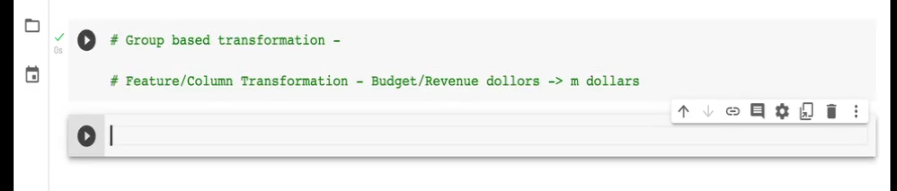

In [31]:
# asssess every movie wrt director average budget 

In [83]:
data["budget"]

0       237.000
1       300.000
2       245.000
3       250.000
4       258.000
         ...   
1460      0.000
1461      0.027
1462      0.000
1463      0.000
1464      0.220
Name: budget, Length: 1465, dtype: float64

In [84]:
def substract_avg(x):
  x["additional_budget"] = x["budget"] - x["budget"].mean()

data.groupby("director_name").transform(substract_avg)

KeyError: 'budget'

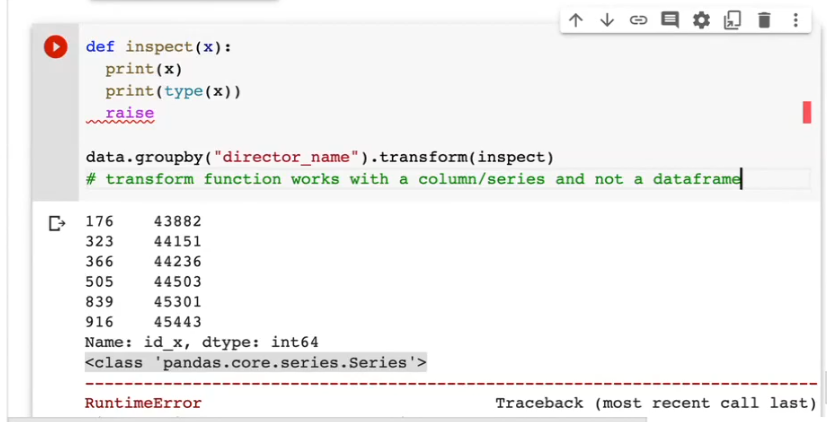

In [ ]:
def substract_avg(x):
  return x - x.mean()

data["additional_budget"] = data.groupby("director_name")["budget"].transform(substract_avg)

In [39]:
data

,Unnamed: 0,id_x,budget,popularity,revenue,title,vote_average,vote_count,year,month,day,director_name,gender,additional_budget
0,0,43597,237.000,150,2787.965087,Avatar,7.2,11800,2009,Dec,Thursday,James Cameron,Male,130.300000
1,1,43598,300.000,139,961.000000,Pirates of the Caribbean: At World's End,6.9,4500,2007,May,Saturday,Gore Verbinski,Male,141.857143
2,2,43599,245.000,107,880.674609,Spectre,6.3,4466,2015,Oct,Monday,Sam Mendes,Male,150.142857
3,3,43600,250.000,112,1084.939099,The Dark Knight Rises,7.6,9106,2012,Jul,Monday,Christopher Nolan,Male,124.375000
4,5,43602,258.000,115,890.871626,Spider-Man 3,5.9,3576,2007,May,Tuesday,Sam Raimi,Male,174.004545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,4736,48363,0.000,3,0.321952,The Last Waltz,7.9,64,1978,May,Monday,Martin Scorsese,Male,-47.478947
1461,4743,48370,0.027,19,3.151130,Clerks,7.4,755,1994,Sep,Tuesday,Kevin Smith,Male,-11.979417
1462,4748,48375,0.000,7,0.000000,Rampage,6.0,131,2009,Aug,Friday,Uwe Boll,Male,-21.700000
1463,4749,48376,0.000,3,0.000000,Slacker,6.4,77,1990,Jul,Friday,Richard Linklater,Male,-10.890909


# for a movie , if it was risky for a director or not - whose budget was even higher than average revenue with same director
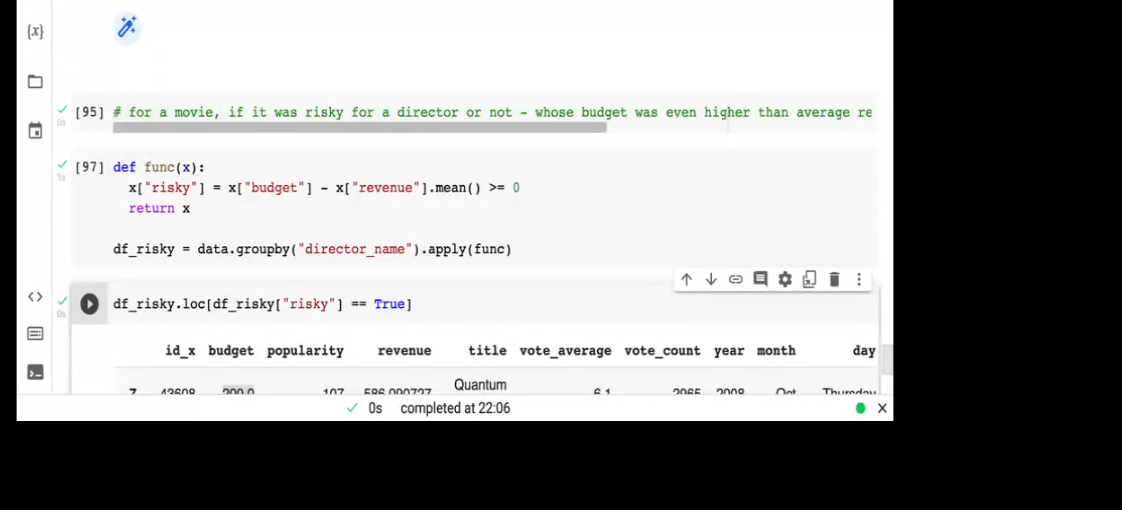  

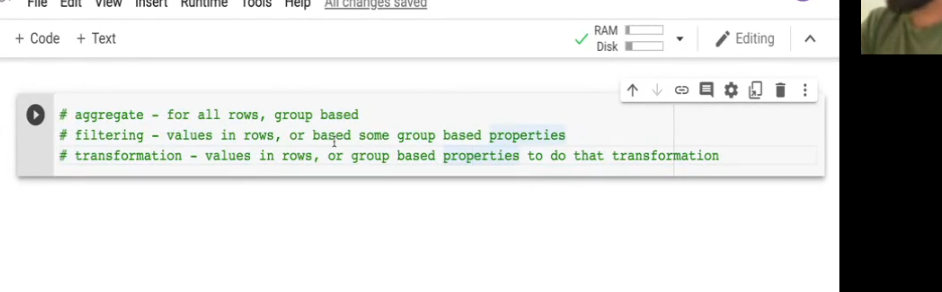

<!-- if a movie if it is rsiky for a director or not -->

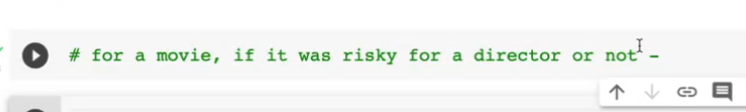

In [86]:
def func(x):
  x["risky"] = x["budget"] - x["revenue"].mean() >= 0
  return x

df_risky = data.groupby("director_name").apply(func)

In [87]:
df_risky.loc[df_risky["risky"]==True]

id_x  budget  popularity     revenue  \
director_name                                                    
Andrzej Bartkowiak 349   44192    60.0          29   55.987321   
Atom Egoyan        946   45538    25.0           4    0.000000   
                   1194  46370    15.0          26    8.459458   
                   1347  47224     5.0           7    3.263585   
Brett Ratner       24    43630   210.0           3  459.359555   
...                        ...     ...         ...         ...   
Uwe Boll           944   45536    25.0           7    2.405420   
                   1058  45834    20.0           9   10.442808   
                   1383  47453     3.5           4    0.000000   
Wayne Wang         468   44419    55.0          19  154.906693   
Zhang Yimou        192   43914    94.0          12   95.311434   

                                               title  vote_average  \
director_name                                                        
Andrzej Bartkowiak 349                          Doom           5.0   
Atom Egoyan        946          Where the Truth Lies           5.9   
                   1194                        Chloe           5.9   
                   1347          The Sweet Hereafter           6.8   
Brett Ratner       24          X-Men: The Last Stand           6.3   
...                                              ...           ...   
Uwe Boll           944                    BloodRayne           3.5   
                   1058            Alone in the Dark           3.1   
                   1383  In the Name of the King III           3.3   
Wayne Wang         468             Maid in Manhattan           5.6   
Zhang Yimou        192            The Flowers of War           7.1   

                         vote_count  year month        day gender  \
director_name                                                       
Andrzej Bartkowiak 349          609  2005   Oct   Thursday   Male   
Atom Egoyan        946           66  2005   Oct     Friday   Male   
                   1194         498  2009   Mar  Wednesday   Male   
                   1347         103  1997   May  Wednesday   Male   
Brett Ratner       24          3525  2006   May  Wednesday   Male   
...                             ...   ...   ...        ...    ...   
Uwe Boll           944          118  2005   Oct   Saturday   Male   
                   1058         173  2005   Jan     Friday   Male   
                   1383          19  2013   Dec     Friday   Male   
Wayne Wang         468          485  2002   Dec     Friday    NaN   
Zhang Yimou        192          187  2011   Dec   Thursday   Male   

                         additional_budget  risky  
director_name                                      
Andrzej Bartkowiak 349           18.000000   True  
Atom Egoyan        946           17.500000   True  
                   1194           7.500000   True  
                   1347          -2.500000   True  
Brett Ratner       24           119.666667   True  
...                                    ...    ...  
Uwe Boll           944            3.300000   True  
                   1058          -1.700000   True  
                   1383         -18.200000   True  
Wayne Wang         468           27.573199   True  
Zhang Yimou        192           73.166648   True  

[131 rows x 13 columns]